# Módulo 1 — Filtros e Funções Base



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy import signal
from scipy.signal import iirnotch, filtfilt
import pywt
import wfdb

## Introdução

Vou fazer uma comparação de um sinal original de ECG e, depois, desse mesmo sinal com a adição de ruídos. A ideia é observar como cada interferência altera o comportamento do sinal ao longo do tempo.

## Fórmulas no Domínio do Tempo

O ECG sintético foi modelado como a soma de pulsos gaussianos centrados em cada batimento:

$$x_{ECG}(t)=\sum_{k} \exp\left(-\frac{(t-t_k)^2}{2\sigma^2}\right)$$

Os ruídos adicionados foram:

$$n_1(t)=\sin(2\pi\cdot 60\,t), \quad n_2(t)=\sin(2\pi\cdot 0.2\,t), \quad n_3(t)\sim \mathcal{N}(0,1)$$

E o sinal final ruidoso foi definido por:

$$x_{r}(t)=x_{ECG}(t)+n_1(t)+n_2(t)+n_3(t)$$

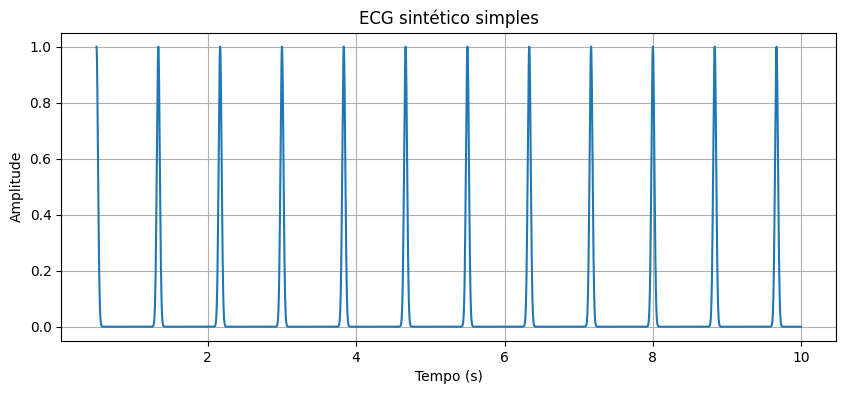

In [2]:
frequencia_amostragem = 360 # 360 hz
duracao = 10 # 10 segundos
frequencia_cardiaca = 1.2 # frequencia cardiaca (hz) 72 bpm

tempo = np.arange(0.5, duracao, 1/frequencia_amostragem)

ecg = np.zeros_like(tempo)

# Instantes dos batimentos
batimentos = np.arange(0.5, duracao, 1/frequencia_cardiaca)

# Adiciona uma gaussiana em cada batimento
for centro in batimentos:
    ecg += np.exp(-((tempo - centro)**2)/(2*0.02**2))

# Plot
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("ECG sintético simples")
plt.grid()
plt.show()

# Algoritmo LMS (Least Mean Squares)

## Saída do filtro

$$y[n] = \sum_{k=0}^{M-1} w_k[n-1]\, x[n-k]$$

## Erro

$$e[n] = d[n] - y[n]$$

## Atualização dos coeficientes

$$w_k[n] = w_k[n-1] + 2\mu\, e[n]\, x[n-k]$$

## Forma vetorial

Vetores de entrada e de pesos:

$$\mathbf{x}[n] = \begin{bmatrix} x[n] \\ x[n-1] \\ \vdots \\ x[n-M+1] \end{bmatrix}, \qquad
\mathbf{w}[n-1] = \begin{bmatrix} w_0[n-1] \\ w_1[n-1] \\ \vdots \\ w_{M-1}[n-1] \end{bmatrix}$$

Saída e atualização:

$$y[n] = \mathbf{w}^T[n-1]\,\mathbf{x}[n]$$

$$\mathbf{w}[n] = \mathbf{w}[n-1] + 2\mu\, e[n]\,\mathbf{x}[n]$$

## Definições

| Símbolo | Descrição |
|---------|-----------|
| $\mathbf{x}[n]$ | Sinal de referência (60 Hz) |
| $d[n]$ | Sinal desejado (ECG + ruído) |
| $y[n]$ | Estimativa do ruído |
| $e[n]$ | Sinal filtrado (saída) |
| $M$ | Ordem do filtro |
| $\mu$ | Passo de adaptação |

## Interpretação

O LMS ajusta um filtro FIR variante no tempo para minimizar o erro quadrático médio:

$$J = E\!\left[e^2[n]\right]$$

In [3]:
def lms_filter(d, x, mu, M):
    """
    d: sinal primário (ruidoso)
    x: sinal de referência (correlacionado com o ruído)
    mu: passo de adaptação
    M: ordem do filtro (nº de coeficientes)
    """
    N = len(d) #numero de amostras do meu sinal
    w = np.zeros(M) #peso para atualizar
    y = np.zeros(N) #saida intermediaria para ccomparar com o sinal real e calcular o erro
    e = np.zeros(N) #erro
    w_history = np.zeros((N, M)) #historico

    # Processa o sinal amostra por amostra
    for n in range(M, N):
        # Monta a janela de entrada com as M amostras mais recentes
        x_n = x[n-M:n][::-1]

        # Calcula a saída atual do filtro adaptativo
        y[n] = np.dot(w, x_n)

        # Calcula o erro entre o sinal desejado e a saída do filtro
        e[n] = d[n] - y[n]

        # Atualiza os coeficientes do filtro usando a regra LMS
        w = w + 2 * mu * e[n] * x_n
        w_history[n] = w

    return e, y, w_history

### NLMS (Normalized Least Mean Squares)

O algoritmo NLMS é uma versão normalizada do LMS que adapta automaticamente o passo de adaptação com base na potência do sinal de entrada. Isso oferece melhor convergência e estabilidade em comparação com o LMS padrão.

A diferença principal está na atualização dos pesos:

$$\mathbf{w}[n] = \mathbf{w}[n-1] + \frac{\mu}{\|\mathbf{x}[n]\|^2 + \epsilon} e[n] \mathbf{x}[n]$$

onde:
- O denominador $\|\mathbf{x}[n]\|^2$ normaliza o passo de adaptação pela potência do sinal de entrada
- $\epsilon$ é um pequeno valor (geralmente $10^{-6}$) para evitar divisão por zero
- Isso torna o NLMS menos sensível à variação da potência do sinal de referência

In [4]:
def nlms_filter(d, x, mu, M, eps=1e-6):
    N = len(d)
    w = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    w_history = np.zeros((N, M))

    for n in range(M, N):
        x_n = x[n-M:n][::-1]
        y[n] = np.dot(w, x_n)
        e[n] = d[n] - y[n]
        norm = np.dot(x_n, x_n) + eps
        w = w + (mu / norm) * e[n] * x_n
        w_history[n] = w

    return e, y, w_history

## DWT (Discrete Wavelet Transform)

A DWT decompõe o sinal em coeficientes de aproximação (baixa frequência)
e de detalhe (alta frequência), em múltiplos níveis.

Para remover ruído, aplica-se um threshold nos coeficientes de detalhe:
coeficientes pequenos (ruído) → zerados
coeficientes grandes (sinal real) → mantidos

Reconstruindo o sinal com os coeficientes modificados, obtemos o sinal limpo.

In [5]:
def dwt_filter(sinal, wavelet='db4', nivel=6):
    """
    Remove ruído via DWT com threshold de Donoho & Johnstone.

    Parâmetros
    ----------
    sinal   : array — sinal ruidoso de entrada
    wavelet : str   — família wavelet (padrão: db4)
    nivel   : int   — níveis de decomposição

    Retorno
    -------
    sinal_filtrado : array
    """
    coeffs = pywt.wavedec(sinal, wavelet, level=nivel)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thr    = sigma * np.sqrt(2 * np.log(len(sinal)))
    coeffs_f = [coeffs[0]] + [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs_f, wavelet)[:len(sinal)]


## Métrica de Qualidade (SNR)

A relação sinal-ruído foi calculada pela razão entre a potência do sinal limpo e a potência do erro:

$$P_s=\frac{1}{N}\sum_{n=0}^{N-1}x_{limpo}^2[n], \quad P_e=\frac{1}{N}\sum_{n=0}^{N-1}(x_{ruidoso}[n]-x_{limpo}[n])^2$$

$$\mathrm{SNR}_{dB}=10\log_{10}\left(\frac{P_s}{P_e}\right)$$

In [6]:
def comparar_sinais(sinal_limpo, sinal_ruidoso):
    potencia_sinal = np.mean(sinal_limpo**2)
    erro = sinal_ruidoso - sinal_limpo
    potencia_erro = np.mean(erro**2)
    snr = 10 * np.log10(potencia_sinal / potencia_erro)
    print("Potência sinal:", potencia_sinal)
    print("Potência erro:", potencia_erro)
    return snr

In [7]:
def snr_estimado(sinal_limpo, sinal_filtrado):
    """Alias de comparar_sinais para uso nos módulos de sinais reais."""
    return comparar_sinais(sinal_limpo, sinal_filtrado)
